## Importing the dependencies


In [3]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn import metrics

### Dataset features  
Car Brand  
Year  
Sold price    
Present price  
KMS driven  
Fuel type  
Seller type  
Transmission type  
Owners  


## Data collection and processing

In [6]:
car_dataset=pd.read_csv("car data.csv")
car_dataset

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [7]:
car_dataset.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [8]:
car_dataset.shape

(301, 9)

In [9]:
car_dataset.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [10]:
car_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [11]:
## change Year to datetime

### Check missing values

In [13]:
car_dataset.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [16]:
## checking the distribution of categorical data
car_dataset.Fuel_Type.value_counts()

Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64

In [17]:
car_dataset.Seller_Type.value_counts()

Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64

In [18]:
car_dataset.Transmission.value_counts()

Transmission
Manual       261
Automatic     40
Name: count, dtype: int64

### Encoding categorical values 

In [20]:
## encoding the fuel type column
car_dataset.replace({'Fuel_Type':{'Petrol':0,'Diesel':1,'CNG':2}},inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_14924\728977423.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  car_dataset.replace({'Fuel_Type':{'Petrol':0,'Diesel':1,'CNG':2}},inplace=True)


In [21]:
## encoding the seller type column
car_dataset.replace({'Seller_Type':{'Dealer':0,'Individual':1}},inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_14924\943612413.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  car_dataset.replace({'Seller_Type':{'Dealer':0,'Individual':1}},inplace=True)


In [22]:
## encoding the Transmission column
car_dataset.replace({'Transmission':{'Manual':0,'Automatic':1}},inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_14924\309586384.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  car_dataset.replace({'Transmission':{'Manual':0,'Automatic':1}},inplace=True)


In [23]:
## encoding the fuel type column
car_dataset.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,0,0,0,0
1,sx4,2013,4.75,9.54,43000,1,0,0,0
2,ciaz,2017,7.25,9.85,6900,0,0,0,0
3,wagon r,2011,2.85,4.15,5200,0,0,0,0
4,swift,2014,4.60,6.87,42450,1,0,0,0


## Splitting our data into training data and test data

In [27]:
X=car_dataset.drop(['Car_Name','Selling_Price'],axis=1)
X

,Year,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,2014,5.59,27000,0,0,0,0
1,2013,9.54,43000,1,0,0,0
2,2017,9.85,6900,0,0,0,0
3,2011,4.15,5200,0,0,0,0
4,2014,6.87,42450,1,0,0,0
...,...,...,...,...,...,...,...
296,2016,11.60,33988,1,0,0,0
297,2015,5.90,60000,0,0,0,0
298,2009,11.00,87934,0,0,0,0
299,2017,12.50,9000,1,0,0,0


In [30]:
Y=car_dataset['Selling_Price']
Y

0       3.35
1       4.75
2       7.25
3       2.85
4       4.60
       ...  
296     9.50
297     4.00
298     3.35
299    11.50
300     5.30
Name: Selling_Price, Length: 301, dtype: float64

In [33]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.1,random_state=2)

In [34]:
X_train.shape

(270, 7)

In [35]:
Y_train.shape

(270,)

In [36]:
X_test.shape

(31, 7)

In [38]:
Y_test.shape

(31,)

## Model Training

### 1.LinearRegression

In [39]:
lin_reg_model=LinearRegression()

In [41]:
lin_reg_model.fit(X_train,Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Model evaluation

#### prediction on training data


In [42]:
trainig_data_prediction=lin_reg_model.predict(X_train)


In [53]:
## R squared Error
error_score=metrics.r2_score(Y_train,trainig_data_prediction)
print(f'R squared error : {error_score:.2f}')

R squared error : 0.88


### visualize the actual prices and predicted prices

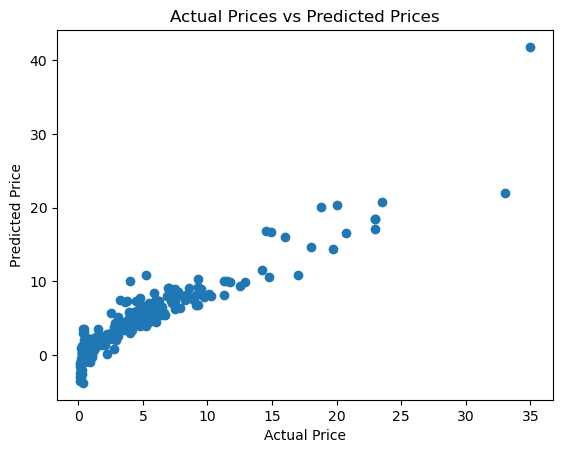

In [56]:
plt.scatter(Y_train,trainig_data_prediction)
plt.title('Actual Prices vs Predicted Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.savefig('ActualPricesVsPredictedPrices.png',bbox_inches='tight')
plt.show()

In [57]:
test_data_prediction=lin_reg_model.predict(X_test)

In [58]:
error_score=metrics.r2_score(Y_test,test_data_prediction)
print(f'R squared error : {error_score:.2f}')

R squared error : 0.84


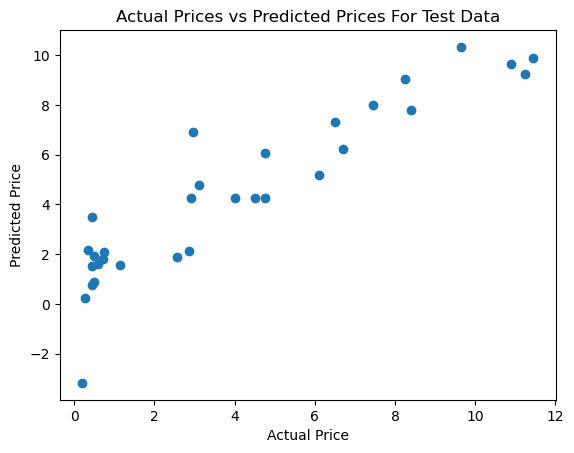

In [60]:
plt.scatter(Y_test,test_data_prediction)
plt.title('Actual Prices vs Predicted Prices For Test Data')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.savefig('ActualPricesVsPredictedPrices4TestData.png',bbox_inches='tight')
plt.show()

### 2.Lasso Regression

In [62]:
lasso_reg_model=Lasso()

In [63]:
lasso_reg_model.fit(X_train,Y_train)

,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [71]:
training_data_prediction=lasso_reg_model.predict(X_train)

In [72]:
## R squared Error 4 trina data
error_score=metrics.r2_score(Y_train,training_data_prediction)
print(f'R squared error : {error_score:.2f}')

R squared error : 0.84


In [73]:
test_data_prediction=lasso_reg_model.predict(X_test)

In [74]:
## R squared Error
error_score=metrics.r2_score(Y_test,test_data_prediction)
print(f'R squared error : {error_score:.2f}')

R squared error : 0.87


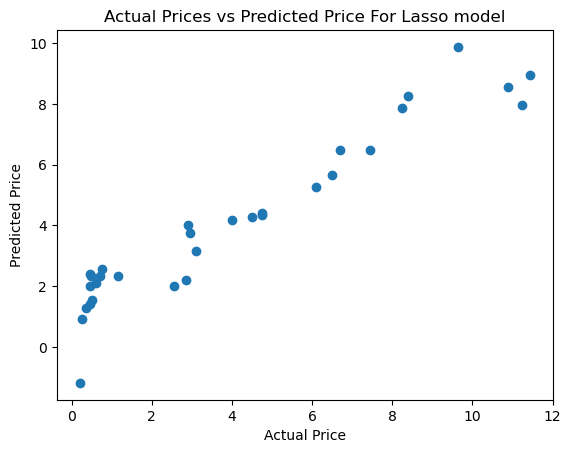

In [75]:
plt.scatter(Y_test,test_data_prediction)
plt.title('Actual Prices vs Predicted Price For Lasso model')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.savefig('ActualPricesVsPredictedPrices4LassoModel.png',bbox_inches='tight')
plt.show()